## 1. Research Question

What limits fine-scale spatial reconstruction in terrain-aware ERA5→PRISM downscaling?

ERA5→PRISM is not simple super-resolution because PRISM contains station-informed, terrain-aware spatial structure that is only partly implied by coarse ERA5 fields. The model is reconstructing a different climate data product, not only resizing an image.

Blurry outputs are the expected MSE solution under information deficit. If one ERA5 state is consistent with many fine-scale PRISM realizations, the conditional mean is smooth, so blur is not by itself evidence of a broken model.


## 2. Physics Baselines (no model training)

These baselines set the scale of the problem before any learned model is used. Bilinear ERA5 measures what coarse atmospheric interpolation already gives; the lapse-rate correction tests whether the residual is mostly a simple elevation effect.


In [14]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / "docs").exists():
    for parent in ROOT.parents:
        if (parent / "docs").exists() and (parent / "notebooks").exists():
            ROOT = parent
            break

pd.DataFrame([
    {"Baseline": "Persistence", "RMSE (°C)": "—"},
    {"Baseline": "Bilinear ERA5", "RMSE (°C)": 3.4580},
    {"Baseline": "Lapse-rate corrected ERA5", "RMSE (°C)": 3.4525},
])


,Baseline,RMSE (°C)
0,Persistence,—
1,Bilinear ERA5,3.458
2,Lapse-rate corrected ERA5,3.4525


Terrain geometry (elevation, slope, aspect) explains only 5.4% of daily PRISM residual variance. The standard lapse-rate correction improves RMSE by 0.005°C over bilinear ERA5. The ERA5→PRISM residual in January Georgia is not primarily a terrain correction problem.


## 3. Residual Structure

The residual is `PRISM - bilinear ERA5`. Separating the temporal mean residual from day-to-day residual variability shows what part is stable spatial bias and what part changes with weather.


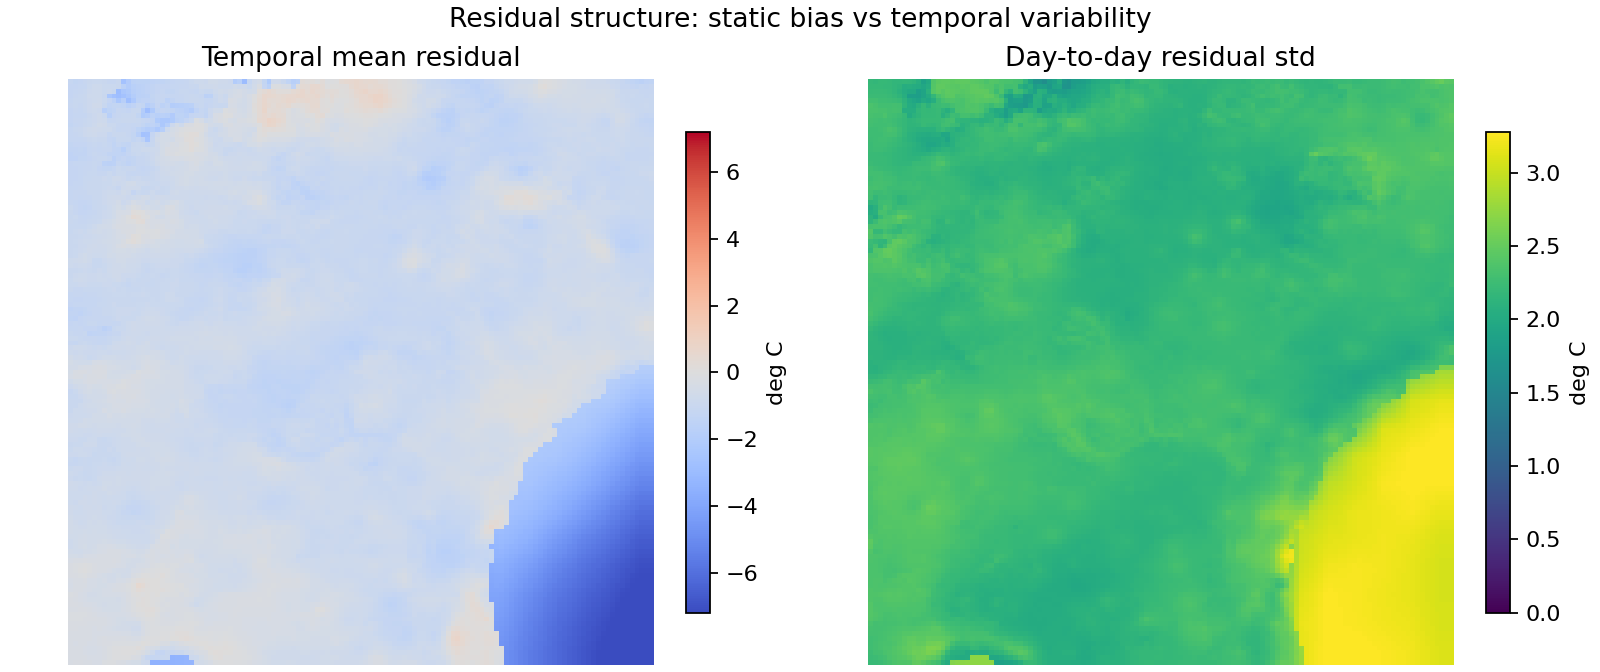

In [15]:
display(Image(filename=str(ROOT / "docs" / "images" / "residual_structure_panels.png")))


The temporal mean residual (static bias) is the terrain correction component that does not change day to day. The model should learn this most easily. The day-to-day variability is atmospheric and requires more data to learn reliably.


## 4. Single-Sample Overfit: Pipeline Sanity

The one-sample overfit test checks whether the U-Net training path, residual reconstruction, normalization, and gradients are working at all. A correct pipeline should steadily fit one fixed example with a fixed learning rate and no scheduler.


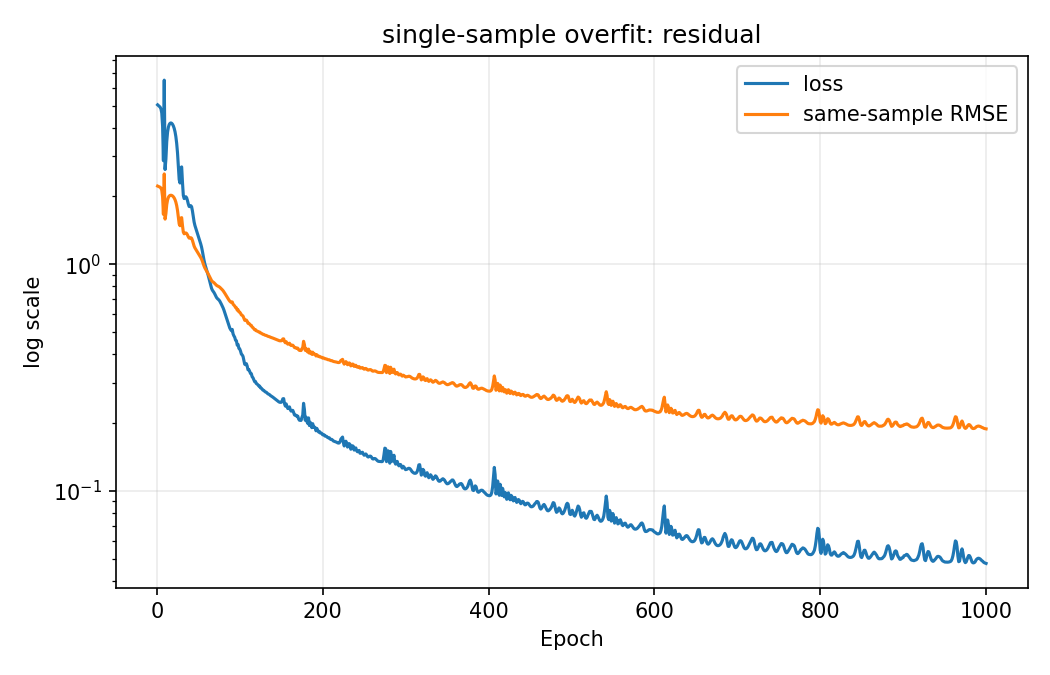

In [16]:
display(Image(filename=str(ROOT / "docs" / "images" / "overfit_loss_curve_log.png")))


In [17]:
pd.DataFrame([
    {"Epoch": 1, "RMSE (°C)": 2.211},
    {"Epoch": 100, "RMSE (°C)": 0.614},
    {"Epoch": 500, "RMSE (°C)": 0.251},
    {"Epoch": 1000, "RMSE (°C)": 0.1875},
])


,Epoch,RMSE (°C)
0,1,2.2110
1,100,0.6140
2,500,0.2510
3,1000,0.1875


The loss decays smoothly on log scale without a sharp early plateau. This confirms the pipeline is functioning correctly. The non-zero floor (0.1875°C on a residual with std 1.69°C) reflects the information limit of the inputs, not a broken optimizer.


## 5. Reconstruction Comparison

This fixed-sample panel compares the PRISM target, the residual U-Net with PixelShuffle upsampling, and the bilinear ERA5 baseline on the same Celsius color scale.


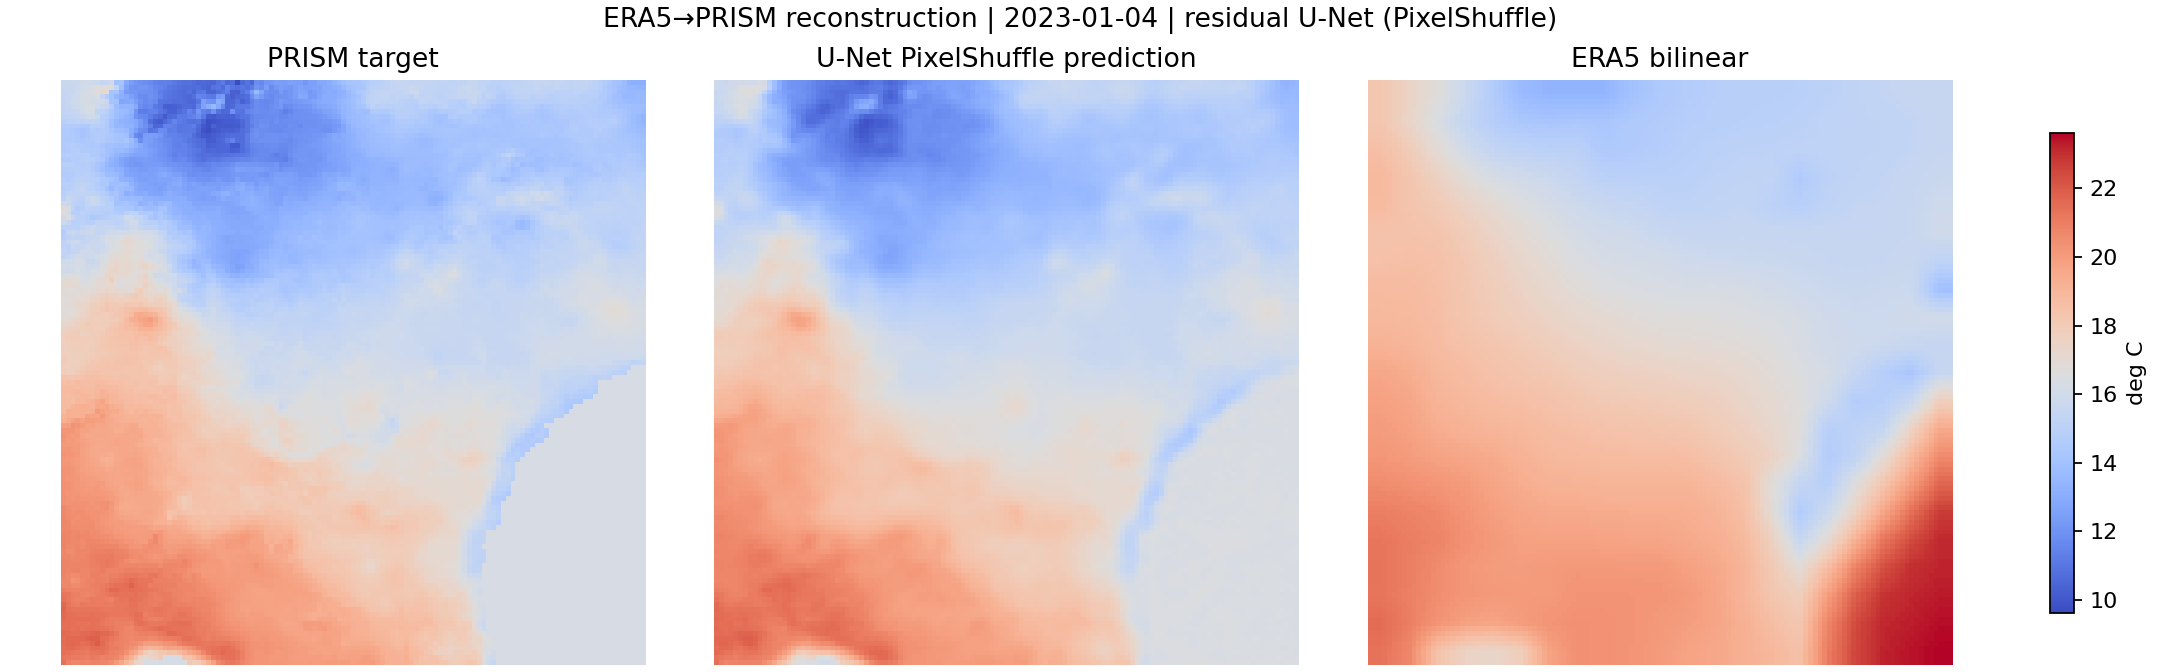

In [18]:
display(Image(filename=str(ROOT / "docs" / "images" / "reconstruction_comparison_pixelshuffle.png")))


Left: PRISM target. Center: U-Net PixelShuffle prediction. Right: ERA5 bilinear baseline. The PixelShuffle decoder produces visible terrain-driven spatial structure that bilinear ERA5 lacks, but fine PRISM-scale texture remains partially unresolved due to data scale limitations.


## 6. Spatial Frequency Analysis

The PSD comparison measures how much spatial power is retained at different wavelengths. Short wavelengths correspond to PRISM-scale detail; low retention means the reconstruction path is smoothing out local structure.


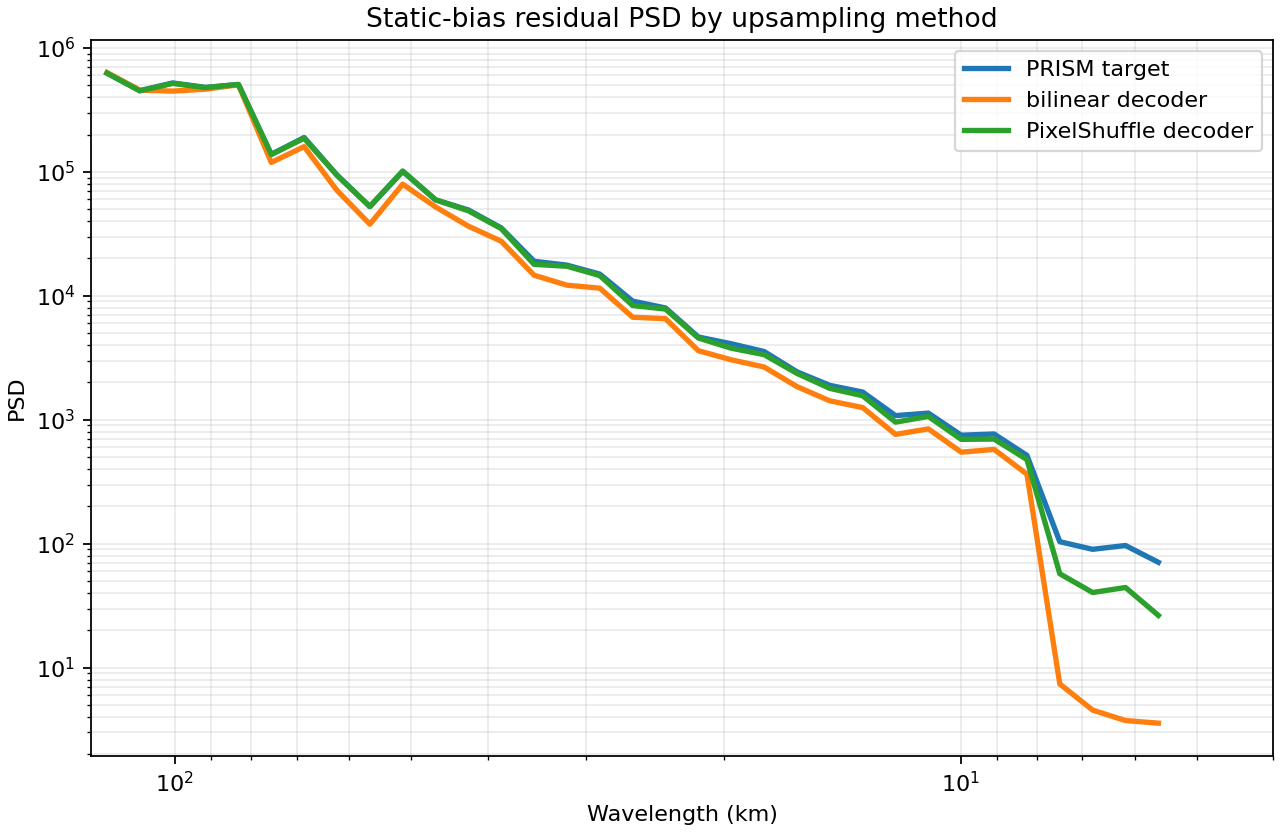

In [19]:
display(Image(filename=str(ROOT / "docs" / "images" / "psd_comparison_upsampling.png")))


In [20]:
pd.DataFrame([
    {"Band": "4–8 km", "Bilinear retention": 0.0693, "PixelShuffle retention": 0.5397},
    {"Band": "8–16 km", "Bilinear retention": 0.7503, "PixelShuffle retention": 0.9148},
    {"Band": "16–32 km", "Bilinear retention": 0.7783, "PixelShuffle retention": "—"},
])


,Band,Bilinear retention,PixelShuffle retention
0,4–8 km,0.0693,0.5397
1,8–16 km,0.7503,0.9148
2,16–32 km,0.7783,—


At 4–8 km (PRISM native scale), bilinear upsampling retains only 6.9% of spatial content. PixelShuffle raises this to 53.97% on a controlled target. The bilinear decoder was producing predictions with lower spatial frequency content than bilinear ERA5 interpolation alone — meaning it was removing structure that interpolation already had.


## 7. Boundary Gradient Analysis

Boundary and edge behavior is evaluated with Sobel gradient maps. This directly checks whether reconstructed temperature transitions align with PRISM's sharper spatial gradients.


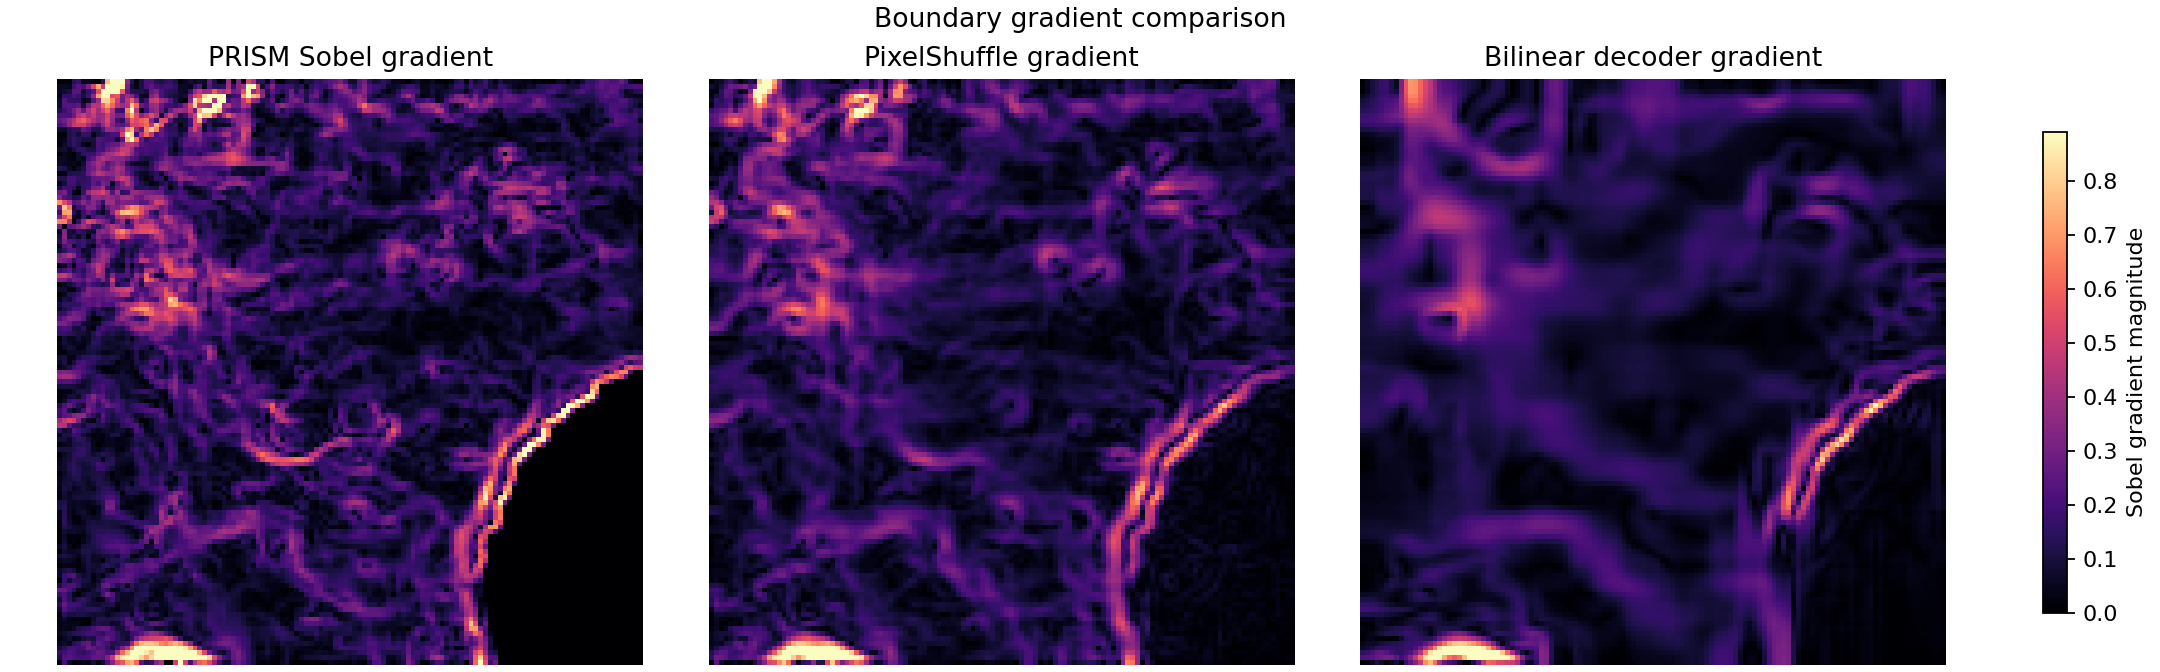

In [21]:
display(Image(filename=str(ROOT / "docs" / "images" / "boundary_gradient_comparison.png")))


In [22]:
pd.DataFrame([
    {"Method": "U-Net bilinear", "Gradient Pearson r vs PRISM": 0.7487},
    {"Method": "U-Net PixelShuffle", "Gradient Pearson r vs PRISM": 0.9042},
])


,Method,Gradient Pearson r vs PRISM
0,U-Net bilinear,0.7487
1,U-Net PixelShuffle,0.9042


Spatial gradient correlation measures whether temperature transitions across space match PRISM's terrain-driven gradients. PixelShuffle improves this from 0.75 to 0.90, directly addressing the boundary blurriness Prof. Hu identified.


## 8. Skip Connection Ablation

The skip ablation compares the same U-Net path with and without skip features. This isolates whether skip connections improve boundary behavior and high-frequency retention.


In [23]:
pd.DataFrame([
    {"Metric": "Border RMSE (°C)", "With skips": 0.2090, "Without skips": 0.2827},
    {"Metric": "HF retention", "With skips": 0.7834, "Without skips": 0.7491},
])


,Metric,With skips,Without skips
0,Border RMSE (°C),0.2090,0.2827
1,HF retention,0.7834,0.7491


Skip connections reduce border RMSE by 26% and improve high-frequency retention. However, ERA5-resolution skip features carry only 9.74% of PRISM-scale (4-8 km) spatial content because ERA5 itself has no sub-grid atmospheric information at that scale. Skip connections help but cannot create information absent from the inputs.


## 9. Recoverable Spatial Scale

This final check asks which wavelength bands are actually recoverable from ERA5, topography, and the current residual U-Net pipeline. It uses saved checkpoints and validation outputs; no training runs inside the notebook.


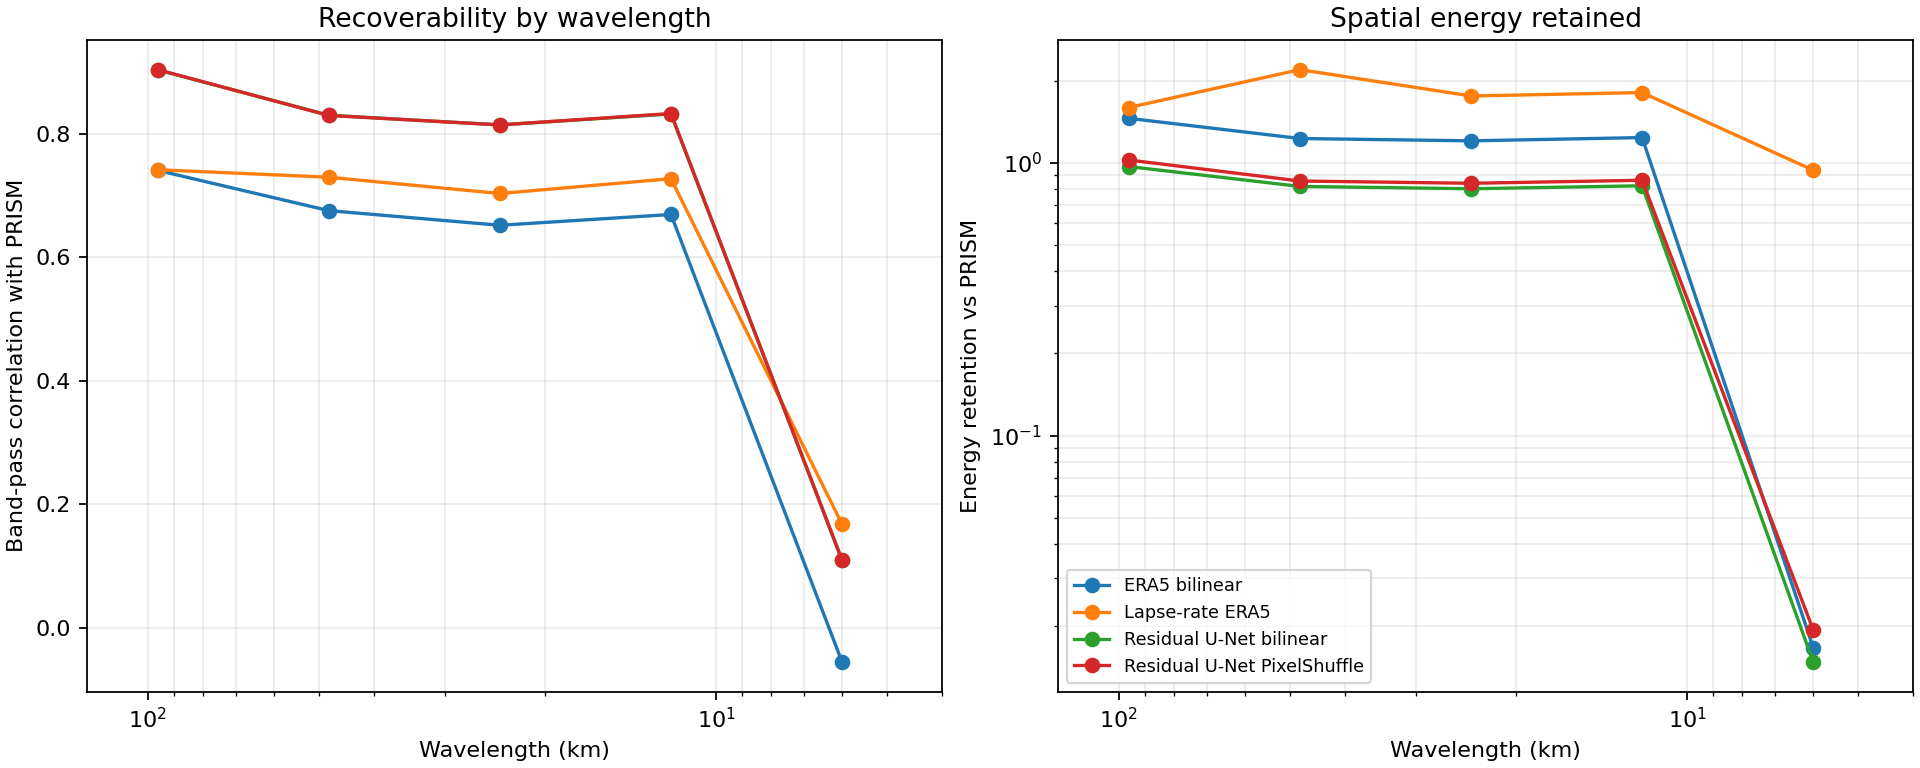

In [24]:
display(Image(filename=str(ROOT / "docs" / "images" / "recoverability_curve.png")))


In [25]:
pd.DataFrame([
    {"Band": ">64 km", "U-Net bilinear corr": 0.904, "U-Net PixelShuffle corr": 0.904, "PixelShuffle retention": 1.026},
    {"Band": "32–64 km", "U-Net bilinear corr": 0.830, "U-Net PixelShuffle corr": 0.830, "PixelShuffle retention": 0.859},
    {"Band": "16–32 km", "U-Net bilinear corr": 0.815, "U-Net PixelShuffle corr": 0.815, "PixelShuffle retention": 0.843},
    {"Band": "8–16 km", "U-Net bilinear corr": 0.832, "U-Net PixelShuffle corr": 0.833, "PixelShuffle retention": 0.865},
    {"Band": "4–8 km", "U-Net bilinear corr": 0.109, "U-Net PixelShuffle corr": 0.109, "PixelShuffle retention": 0.019},
])


,Band,U-Net bilinear corr,U-Net PixelShuffle corr,PixelShuffle retention
0,>64 km,0.904,0.904,1.026
1,32–64 km,0.830,0.830,0.859
2,16–32 km,0.815,0.815,0.843
3,8–16 km,0.832,0.833,0.865
4,4–8 km,0.109,0.109,0.019


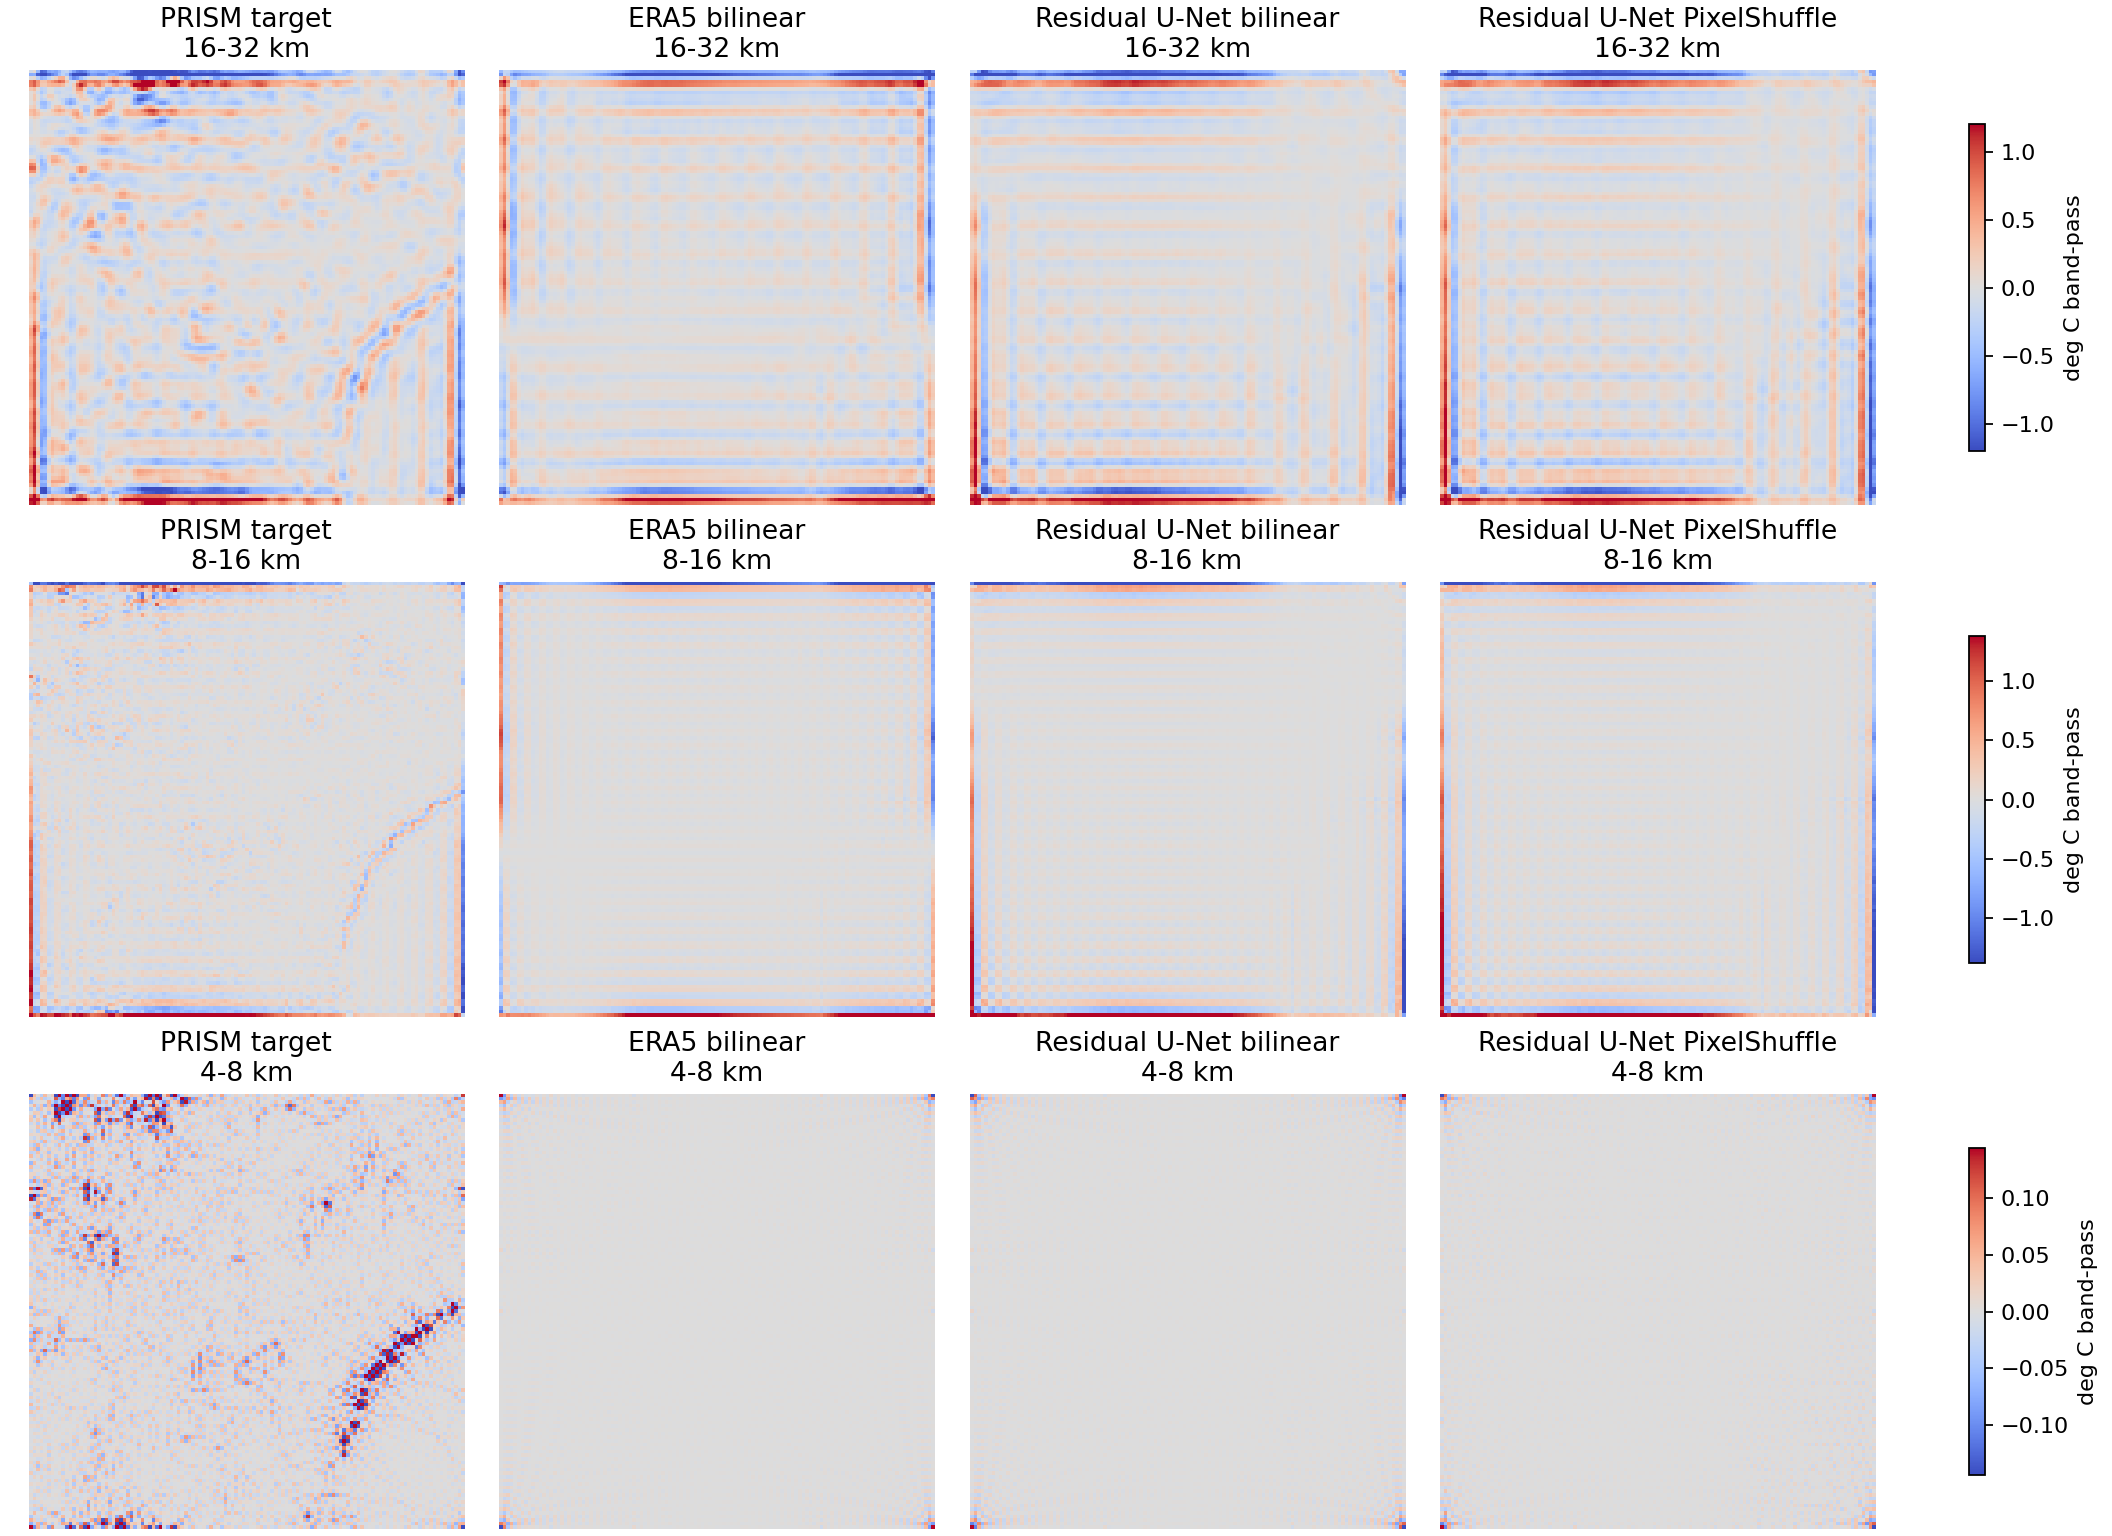

In [26]:
display(Image(filename=str(ROOT / "docs" / "images" / "bandpass_reconstruction_panels.png")))


The learned residual U-Net is useful from broad scales down through roughly 8–16 km. At 4–8 km, near PRISM native scale, correlation collapses. PixelShuffle improves detail diagnostics in controlled settings, but full-validation native-scale recovery is still limited by the available signal and data scale.


## 10. Final Interpretation

| Finding | Evidence |
|---------|----------|
| Terrain R² = 0.054 | Residual not terrain-predictable |
| Residual collapse ratio 0.89 | Model predicts correct-scale residuals |
| Static bias r = 0.986, HF 0.205 | Decoder is the spatial bottleneck |
| 4–8 km retention: 6.9% → 53.97% | PixelShuffle fixes decoder |
| Skip ablation: 26% border improvement | Skips help but are ERA5-limited |
| PixelShuffle RMSE unchanged on full training | Data scale dominates |
| 4–8 km recoverability collapses | PRISM-native detail is not recovered from current inputs |


The primary bottleneck is data scale. The decoder reconstruction pathway has been diagnosed and improved. Fine-scale PRISM reconstruction requires either summer data (stronger terrain signal) or additional observational inputs not present in ERA5.
